# AST V1 Classification: Full-Track Input

This notebook trains and evaluates the first Audio Spectrogram Transformer variant using full-track audio inputs.

The AST model is fine-tuned for music genre classification. Since each track produces one model input, model-input-level and track-level evaluation are identical or directly comparable.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import pandas as pd
from transformers import AutoProcessor, ASTModel, ASTPreTrainedModel, ASTConfig
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torch.nn as nn
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
from src.config import (
    AST_AUDIO_DIR,
    AST_METADATA_CSV,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Die angegebene Prozedur wurde nicht gefunden'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# --- General ---
VERBOSE = 1
MODEL_NAME = "AST_V1"
DATA_DIR = str(AST_AUDIO_DIR)
CSV_FILE = str(AST_METADATA_CSV)
MAX_AUDIO_LENGTH = 30

# --- Dataset ---
REDUCTION_FACTOR = 1   # Percentage of data to keep

# --- Training ---
BATCH_SIZE = 32
MIN_LEARNING_RATE = 1e-6
LEARNING_RATE = 3e-4
EPOCHS = 30
UNFREEZE_EPOCH = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL = "MIT/ast-finetuned-audioset-16-16-0.442"
MAX_AUDIO_LENGTH = 30
ACCUMULATION_STEPS = 4  # Effective batch size = 32 (8 * 4)

# ----------------- FILTER SETTINGS ------------------------
TOP_K_GENRES = 8  # Only keep top K frequent genres (None = all)
EXCLUDE_GENRES = ['International', 'Instrumental', 'Experimental']  # List of genres to exclude
SAMPLES_PER_GENRE = 533  # Max number of samples per genre (None = all)

VAL_SPLIT_RATIO = 0.1  # Validation set ratio
TEST_SPLIT_RATIO = 0.1  # Test set ratio (from total)


In [ ]:
# ============================================================
# DATA REDUCTION FUNCTION
# Keeps only a specified percentage of the dataset
# ============================================================

def reduce_dataset(df, reduction_factor, seed=42):
    """
    Reduce dataset size by randomly sampling a percentage of rows.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    reduction_factor : float
        Fraction of data to keep (0.0 - 1.0).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Reduced dataset.
    """

    if reduction_factor >= 1.0:
        return df

    df_reduced = df.sample(frac=reduction_factor, random_state=RANDOM_STATE)

    if VERBOSE:
        print(f"\nDataset reduced:")
        print(f"Original size: {len(df)}")
        print(f"New size: {len(df_reduced)} ({reduction_factor*100:.1f}%)")

    return df_reduced

In [ ]:
# Create SpecAugment transforms
# These randomly mask parts of the spectrogram during training
freq_masking = T.FrequencyMasking(freq_mask_param=30)  # Masks random frequency bands
time_masking = T.TimeMasking(time_mask_param=100)      # Masks random time segments

def apply_spec_augment(spec):
    """
    Apply SpecAugment to a spectrogram.

    Parameters
    ----------
    spec : torch.Tensor
        Input spectrogram with shape [Batch, Frequency, Time].

    Returns
    -------
    torch.Tensor
        Augmented spectrogram with randomly masked frequency
        and time regions.
    """

    # Apply random frequency masking
    spec = freq_masking(spec)

    # Apply random time masking
    spec = time_masking(spec)

    return spec

In [ ]:
# ----------- LOAD CSV AND FILTER EXISTING FILES ----------- #
df = pd.read_csv(CSV_FILE, dtype={'track_id': str, 'track_genre_top': str})

# Ensure track_id always has 6 digits
df['filename'] = df['track_id'].str.zfill(6) + ".wav"

# Keep only files that exist on disk
existing_files = set(os.listdir(DATA_DIR))
df_filtered = df[df['filename'].isin(existing_files)].reset_index(drop=True)

print(f"Files in CSV: {len(df)}")
print(f"Files found on disk: {len(df_filtered)}")


# ----------- EXCLUDE GENRES AND SELECT TOP K ----------- #

# Remove unwanted genres
if EXCLUDE_GENRES:
    df_filtered = df_filtered[~df_filtered['track_genre_top'].isin(EXCLUDE_GENRES)]
    print(f"Excluded genres: {EXCLUDE_GENRES}")
    print(f"Remaining files: {len(df_filtered)}")

# Select top K most frequent genres
if TOP_K_GENRES is not None:

    genre_counts = df_filtered['track_genre_top'].value_counts()

    top_genres = genre_counts.head(TOP_K_GENRES).index.tolist()

    df_filtered = df_filtered[df_filtered['track_genre_top'].isin(top_genres)]

    print(f"\n--- Filtering Top {TOP_K_GENRES} Genres ---")
    print(f"Remaining genres: {top_genres}")
    print(f"Files after filter: {len(df_filtered)}")


# ----------- OPTIONAL: REDUCE DATASET SIZE ----------- #
df_filtered = reduce_dataset(df_filtered, REDUCTION_FACTOR)


# ----------- BALANCING AND DATA SPLIT ----------- #

train_val_rows, test_rows = [], []
train_rows, val_rows = [], []

grouped = df_filtered.groupby("track_genre_top")

print("\n--- Balancing & Splitting ---")

for genre, group in grouped:

    n_available = len(group)

    # Limit samples per genre if configured
    if SAMPLES_PER_GENRE is not None and n_available > SAMPLES_PER_GENRE:
        group_subset = group.sample(n=SAMPLES_PER_GENRE, random_state=RANDOM_STATE)
        print(f"Genre '{genre}': reduced to {SAMPLES_PER_GENRE}")
    else:
        group_subset = group
        print(f"Genre '{genre}': using {n_available} samples")

    # Split test set
    test_size_n = max(1, int(len(group_subset) * TEST_SPLIT_RATIO))

    train_val_group, test_group = train_test_split(
        group_subset,
        test_size=test_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    test_rows.append(test_group)

    # Split validation set
    val_size_n = max(1, int(len(group_subset) * VAL_SPLIT_RATIO))

    train_group, val_group = train_test_split(
        train_val_group,
        test_size=val_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_rows.append(train_group)
    val_rows.append(val_group)


# Combine final dataframes
train_df = pd.concat(train_rows).reset_index(drop=True)
val_df = pd.concat(val_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)


# ----------- LABEL ENCODER ----------- #
le = LabelEncoder()
le.fit(train_df['track_genre_top'])

print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Files in CSV: 106574
Files found on disk: 103871
Excluded genres: ['International', 'Instrumental', 'Experimental']
Remaining files: 90240

--- Filtering Top 8 Genres ---
Remaining genres: ['Rock', 'Electronic', 'Hip-Hop', 'Folk', 'Pop', 'Classical', 'Jazz', 'Old-Time / Historic']
Files after filter: 33606

--- Balancing & Splitting ---
Genre 'Classical': reduced to 533
Genre 'Electronic': reduced to 533
Genre 'Folk': reduced to 533
Genre 'Hip-Hop': reduced to 533
Genre 'Jazz': reduced to 533
Genre 'Old-Time / Historic': reduced to 533
Genre 'Pop': reduced to 533
Genre 'Rock': reduced to 533
Class mapping: {'Classical': np.int64(0), 'Electronic': np.int64(1), 'Folk': np.int64(2), 'Hip-Hop': np.int64(3), 'Jazz': np.int64(4), 'Old-Time / Historic': np.int64(5), 'Pop': np.int64(6), 'Rock': np.int64(7)}


In [6]:
# ============================================================
# ---------------------- CUSTOM DATASET ---------------------
# ============================================================
class CSVDataset(Dataset):
    """
    PyTorch dataset for audio files and labels.
    Handles loading, padding, mono conversion, resampling, and processor preparation.
    """
    def __init__(self, df, root_dir, processor, max_length=30, le=None):
        self.processor = processor
        self.max_length = max_length
        self.root_dir = root_dir
        self.df = df.copy()
        self.le = le
        # Store labels as integers
        self.df['label'] = self.le.transform(self.df['track_genre_top'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.root_dir, str(row['filename']))
        label = int(row['label'])

        try:
            # Load audio file
            waveform_np, sr = sf.read(file_path, dtype="float32")
            # Ensure 2D: (Channels, Samples)
            if waveform_np.ndim == 1:
                waveform_np = np.expand_dims(waveform_np, axis=0)
            elif waveform_np.ndim == 2 and waveform_np.shape[0] > waveform_np.shape[1]:
                waveform_np = waveform_np.T
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            waveform_np = np.zeros((1, 16000 * self.max_length), dtype="float32")
            sr = 16000

        # Convert to tensor
        waveform = torch.tensor(waveform_np, dtype=torch.float32)

        # Resample to 16 kHz if needed
        if sr != 16000:
            waveform = torch.nn.functional.interpolate(
                waveform.unsqueeze(0),
                size=int(16000 * waveform.shape[1] / sr),
                mode="linear",
                align_corners=False
            ).squeeze(0)

        # Convert stereo to mono by averaging channels
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Cut or pad to exact target length
        target_len = 16000 * self.max_length
        current_len = waveform.shape[1]
        if current_len > target_len:
            waveform = waveform[:, :target_len]
        elif current_len < target_len:
            pad_amount = target_len - current_len
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))

        # Convert back to NumPy for processor
        waveform_final_np = waveform.squeeze().numpy()

        # Process audio with AST processor
        inputs = self.processor(
            waveform_final_np,
            sampling_rate=16000,
            return_tensors="pt"
        )
        input_values = inputs["input_values"].squeeze(0)

        return input_values, torch.tensor(label, dtype=torch.long), row["track_id"]

In [ ]:
class CustomASTClassifier(ASTPreTrainedModel):
    """
    Custom Audio Spectrogram Transformer (AST) classifier with an additional
    trainable head on top. Supports optional freezing of the AST backbone.
    """
    def __init__(self, config, freeze_backbone=False):
        super().__init__(config)
        self.num_labels = config.num_labels

        # -------------------------------
        # AST backbone
        # -------------------------------
        self.audio_spectrogram_transformer = ASTModel(config)
        if freeze_backbone:
            for param in self.audio_spectrogram_transformer.parameters():
                param.requires_grad = False  # Freeze backbone if needed

        # -------------------------------
        # Classifier head with residual connection
        # -------------------------------
        self.head_linear1 = nn.Linear(config.hidden_size, 512)  # First linear layer
        self.head_ln1 = nn.LayerNorm(512)                        # LayerNorm
        self.dropout1 = nn.Dropout(0.4)                         # Dropout for regularization

        self.head_linear2 = nn.Linear(512, 512)                 # Second linear layer (same dimension for residual)
        self.head_ln2 = nn.LayerNorm(512)
        self.dropout2 = nn.Dropout(0.3)

        self.classifier_out = nn.Linear(512, config.num_labels) # Final classification layer

        self.init_weights()  # Initialize weights

    def forward(self, input_values, labels=None, **kwargs):
        """
        Forward pass.

        Args:
            input_values (Tensor): input audio features (e.g., spectrograms)
            labels (Tensor, optional): ground truth labels for computing loss

        Returns:
            dict with 'loss' and 'logits' if labels provided, else logits
        """
        # -------------------------------
        # AST backbone forward
        # -------------------------------
        outputs = self.audio_spectrogram_transformer(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token representation

        # -------------------------------
        # Head forward with residual
        # -------------------------------
        x = self.head_linear1(cls_output)
        x = self.head_ln1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        res = x  # Save for residual connection
        x = self.head_linear2(x)
        x = self.head_ln2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = x + res  # Add residual

        logits = self.classifier_out(x)  # Final logits

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else logits


# -------------------------------
# Initialization
# -------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load AST configuration with number of output labels
config = ASTConfig.from_pretrained(
    MODEL,
    num_labels=8
)

# Load model with optional backbone freezing
model = CustomASTClassifier.from_pretrained(
    MODEL,
    config=config,
    freeze_backbone=False  # True if you want to train only the head initially
)

model.to(DEVICE)
print("Model loaded and ready on device:", DEVICE)

Some weights of CustomASTClassifier were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-16-16-0.442 and are newly initialized: ['classifier_out.bias', 'classifier_out.weight', 'head_linear1.bias', 'head_linear1.weight', 'head_linear2.bias', 'head_linear2.weight', 'head_ln1.bias', 'head_ln1.weight', 'head_ln2.bias', 'head_ln2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and ready on device: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Epoch 1/30 | Train Loss: 2.1760 | Val Loss: 1.9979 | Val Acc: 0.2382
Epoch 2/30 | Train Loss: 1.8392 | Val Loss: 1.5258 | Val Acc: 0.6250
Epoch 3/30 | Train Loss: 1.4188 | Val Loss: 1.2073 | Val Acc: 0.6769
Epoch 4/30 | Train Loss: 1.1766 | Val Loss: 1.1140 | Val Acc: 0.6934
Epoch 5/30 | Train Loss: 1.0861 | Val Loss: 1.0956 | Val Acc: 0.7052
Epoch 5: Unfreezing last 2 transformer layers
Epoch 6/30 | Train Loss: 1.0499 | Val Loss: 1.0912 | Val Acc: 0.7099
Epoch 7/30 | Train Loss: 1.0251 | Val Loss: 1.0848 | Val Acc: 0.7170
Epoch 8/30 | Train Loss: 0.9971 | Val Loss: 1.0758 | Val Acc: 0.7288
Epoch 9/30 | Train Loss: 0.9698 | Val Loss: 1.0735 | Val Acc: 0.7335
Epoch 10/30 | Train Loss: 0.9432 | Val Loss: 1.0699 | Val Acc: 0.7382
Epoch 11/30 | Train Loss: 0.9165 | Val Loss: 1.0778 | Val Acc: 0.7335
Epoch 12/30 | Train Loss: 0.8997 | Val Loss: 1.0669 | Val Acc: 0.7406
Epoch 13/30 | Train Loss: 0.8827 | Val Loss: 1.0664 | Val Acc: 0.7453
Epoch 14/30 | Train Loss: 0.8555 | Val Loss: 1.0615 |

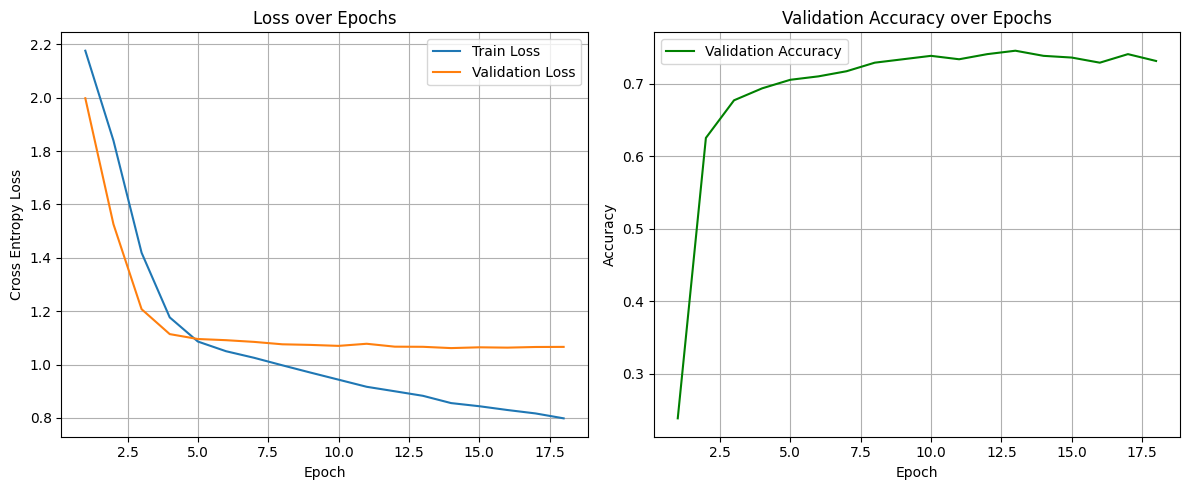

In [ ]:
# ------------------------------------------------------------
# PROCESSOR & MODEL
# ------------------------------------------------------------

# Load the AST processor (handles feature extraction)
processor = AutoProcessor.from_pretrained(MODEL)


# ------------------------------------------------------------
# FREEZE BACKBONE
# ------------------------------------------------------------

# Freeze the full AST backbone to train only the classifier head
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

# Layers of the classification head that remain trainable
head_layers = [
    model.head_linear1,
    model.head_ln1,
    model.head_linear2,
    model.head_ln2,
    model.classifier_out
]

# Enable training for classifier head
for layer in head_layers:
    for param in layer.parameters():
        param.requires_grad = True


# ------------------------------------------------------------
# DATASET & DATALOADER
# ------------------------------------------------------------

# Create dataset objects
train_dataset = CSVDataset(train_df, DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le)
val_dataset   = CSVDataset(val_df, DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le)
test_dataset  = CSVDataset(test_df, DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# ------------------------------------------------------------
# STORAGE FOR TRAINING METRICS
# ------------------------------------------------------------

train_losses = []
val_losses = []
val_accuracies = []


# ------------------------------------------------------------
# TRAINING SETUP
# ------------------------------------------------------------
num_epochs = 30
learning_rate = 2e-5

# Warmup steps (10% of total training steps)
warmup_steps = int(0.1 * len(train_loader) * num_epochs)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=len(train_loader) * num_epochs
)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# TRAINING PARAMETERS
# ------------------------------------------------------------
best_val_loss = float("inf")
patience = 4
patience_counter = 0


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # UNFREEZE LAST TRANSFORMER LAYERS AFTER SOME EPOCHS
    # --------------------------------------------------------
    if epoch == UNFREEZE_EPOCH:

        print(f"Epoch {epoch}: Unfreezing last 2 transformer layers")

        for layer in model.audio_spectrogram_transformer.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Reinitialize optimizer to include newly trainable parameters
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-5,
            weight_decay=1e-4
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * remaining_steps),
            num_training_steps=remaining_steps
        )

    # --------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------

    model.train()
    total_train_loss = 0

    for batch in train_loader:

        inputs = batch[0].to(DEVICE)
        labels = batch[1].to(DEVICE)

        # AST expects input shape [batch, time, frequency]
        # Remove channel dimension if necessary
        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs, labels=labels)
        loss = outputs["loss"]

        # Backpropagation
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)


    # --------------------------------------------------------
    # VALIDATION PHASE
    # --------------------------------------------------------

    model.eval()

    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():

        for batch in val_loader:

            inputs = batch[0].to(DEVICE)
            labels = batch[1].to(DEVICE)

            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            outputs = model(inputs, labels=labels)

            val_loss = outputs["loss"]
            logits = outputs["logits"]

            total_val_loss += val_loss.item()

            preds = torch.argmax(logits, dim=1)

            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_samples

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break


print("\nTraining finished. Creating plots...")


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, epoch + 2)

# Plot loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", color="green")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# ============================================================
def _get_logits(outputs):
    """
    Return logits for both possible model outputs:
    - plain tensor logits
    - dictionary with key 'logits'
    """
    if isinstance(outputs, dict):
        return outputs["logits"]
    return outputs


def collect_segment_predictions(model, loader):
    """
    Run inference once and collect one row per model input.

    In the normal AST setup, one model input usually corresponds to one
    complete track (up to MAX_AUDIO_LENGTH seconds). The same structure is
    nevertheless used as in the 25 x 3-second setup so that segment-level and
    track-level results are directly comparable across notebooks.

    Returns
    -------
    pandas.DataFrame
        Predictions with track_id, true label, predicted label and class
        probabilities for each model input.
    """
    model.eval()

    rows = []

    with torch.no_grad():
        for inputs, labels, track_ids in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # AST expects input shape [batch, time, frequency]
            # Remove an additional channel dimension if one is present.
            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            outputs = model(inputs)
            logits = _get_logits(outputs)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            for track_id, true_label, pred_label, proba in zip(
                track_ids,
                labels.cpu().numpy(),
                predictions.cpu().numpy(),
                probabilities.cpu().numpy()
            ):
                rows.append({
                    "track_id": str(track_id),
                    "true_label": int(true_label),
                    "pred_label": int(pred_label),
                    "true_genre": le.inverse_transform([int(true_label)])[0],
                    "predicted_genre": le.inverse_transform([int(pred_label)])[0],
                    "probabilities": proba
                })

    return pd.DataFrame(rows)


def plot_confusion_matrix_from_labels(y_true, y_pred, title):
    """Plot a confusion matrix for the given labels."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def evaluate_segment_predictions(segment_df, set_name):
    """
    Evaluate predictions on the model-input level.

    For the normal AST setup, this is usually equivalent to track-level
    evaluation because each track is represented by one input. It is still
    reported separately for consistency with the 25 x 3-second experiments.
    """
    print(f"\n--- {set_name} MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---")
    print("Accuracy:", accuracy_score(segment_df["true_label"], segment_df["pred_label"]))
    print("Macro-F1:", f1_score(segment_df["true_label"], segment_df["pred_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        segment_df["true_label"],
        segment_df["pred_label"],
        target_names=le.classes_
    ))

    plot_confusion_matrix_from_labels(
        segment_df["true_label"],
        segment_df["pred_label"],
        f"Confusion Matrix ({set_name}, Model-Input / Segment-Level)"
    )


def aggregate_predictions_to_track(segment_df, method="mean_probability"):
    """
    Aggregate model-input predictions to one prediction per track.

    Parameters
    ----------
    segment_df : pandas.DataFrame
        Output of collect_segment_predictions().
    method : str
        'mean_probability' averages class probabilities per track.
        'majority_vote' uses the most frequent predicted class per track.

    Returns
    -------
    pandas.DataFrame
        One row per track with true label, predicted label, genre names and
        number of model inputs used for aggregation.
    """
    rows = []

    for track_id, group in segment_df.groupby("track_id"):
        true_label = int(group["true_label"].iloc[0])

        if method == "mean_probability":
            prob_matrix = np.stack(group["probabilities"].values)
            mean_probs = prob_matrix.mean(axis=0)
            pred_label = int(np.argmax(mean_probs))

        elif method == "majority_vote":
            pred_label = int(group["pred_label"].value_counts().idxmax())

        else:
            raise ValueError("method must be either 'mean_probability' or 'majority_vote'")

        rows.append({
            "track_id": track_id,
            "true_label": true_label,
            "pred_label": pred_label,
            "true_genre": le.inverse_transform([true_label])[0],
            "predicted_genre": le.inverse_transform([pred_label])[0],
            "n_segments": len(group),
            "aggregation_method": method
        })

    return pd.DataFrame(rows)


def evaluate_track_predictions(track_df, set_name, method):
    """Evaluate one prediction per track after aggregation."""
    print(f"\n--- {set_name} TRACK-LEVEL EVALUATION ({method}) ---")
    print("Accuracy:", accuracy_score(track_df["true_label"], track_df["pred_label"]))
    print("Macro-F1:", f1_score(track_df["true_label"], track_df["pred_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        track_df["true_label"],
        track_df["pred_label"],
        target_names=le.classes_
    ))

    plot_confusion_matrix_from_labels(
        track_df["true_label"],
        track_df["pred_label"],
        f"Confusion Matrix ({set_name}, Track-Level, {method})"
    )



--- Validation MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---
Accuracy: 0.7311320754716981
Macro-F1: 0.7327032748780544

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.57      0.66      0.61        53
               Folk       0.75      0.57      0.65        53
            Hip-Hop       0.78      0.72      0.75        53
               Jazz       0.78      0.74      0.76        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.45      0.51      0.48        53
               Rock       0.72      0.77      0.75        53

           accuracy                           0.73       424
          macro avg       0.74      0.73      0.73       424
       weighted avg       0.74      0.73      0.73       424



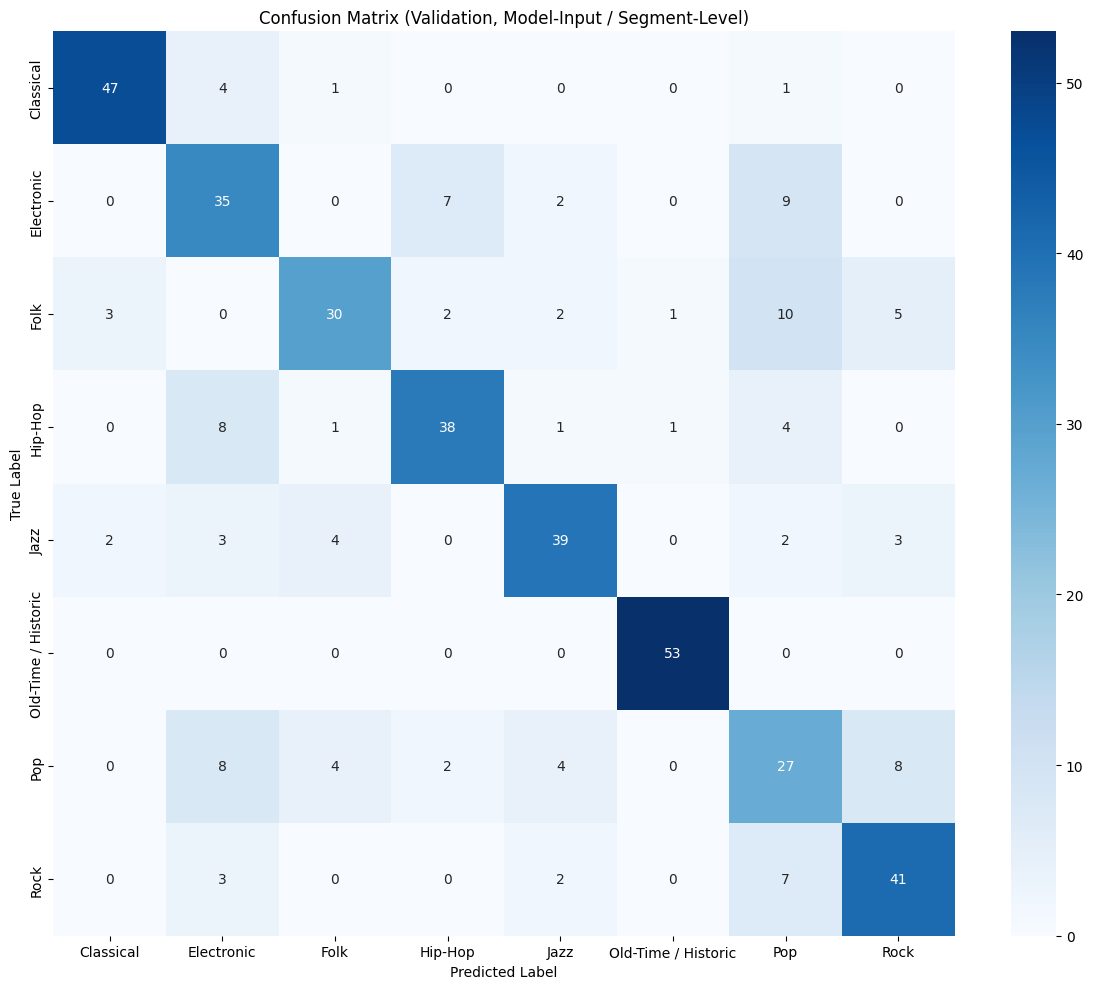


--- Validation TRACK-LEVEL EVALUATION (mean_probability) ---
Accuracy: 0.7311320754716981
Macro-F1: 0.7327032748780544

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.57      0.66      0.61        53
               Folk       0.75      0.57      0.65        53
            Hip-Hop       0.78      0.72      0.75        53
               Jazz       0.78      0.74      0.76        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.45      0.51      0.48        53
               Rock       0.72      0.77      0.75        53

           accuracy                           0.73       424
          macro avg       0.74      0.73      0.73       424
       weighted avg       0.74      0.73      0.73       424



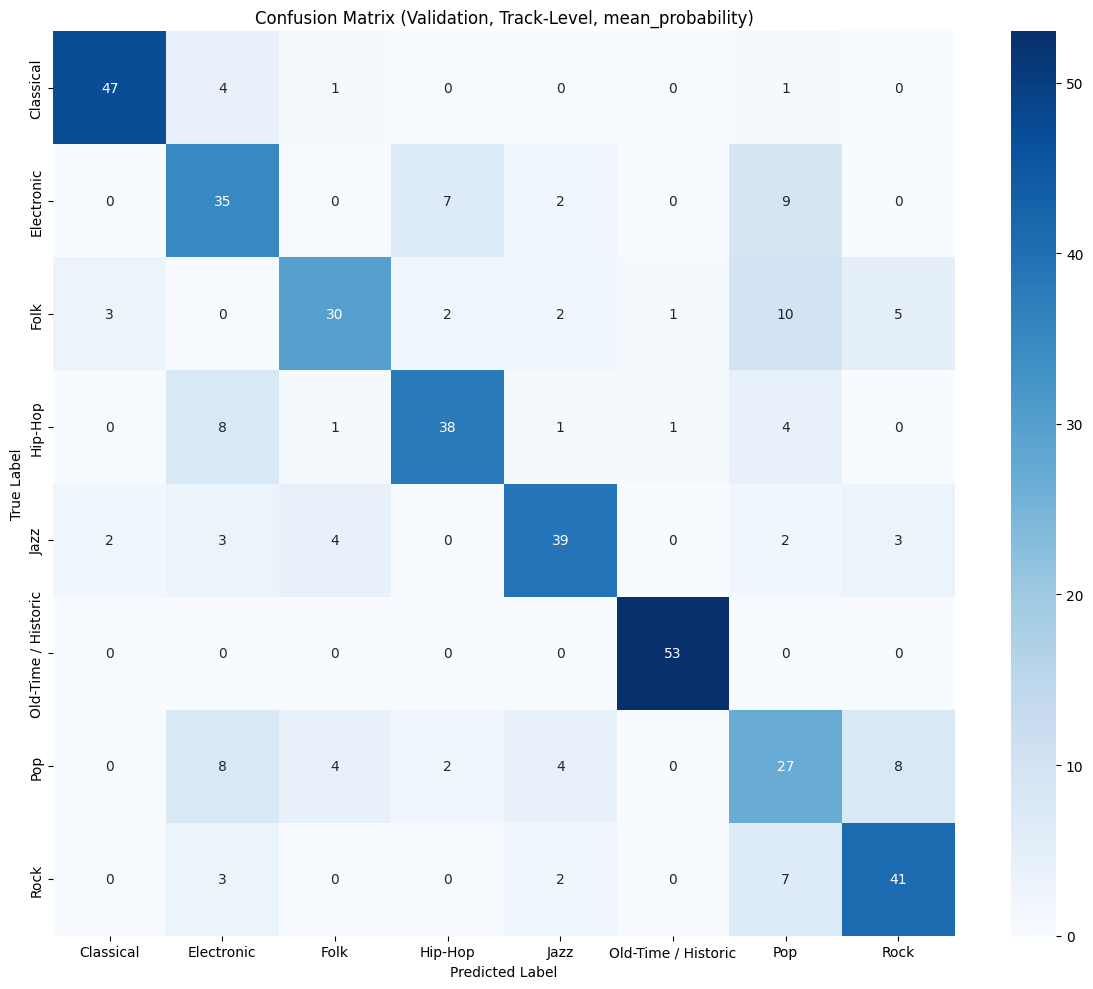


--- Validation TRACK-LEVEL EVALUATION (majority_vote) ---
Accuracy: 0.7311320754716981
Macro-F1: 0.7327032748780544

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.57      0.66      0.61        53
               Folk       0.75      0.57      0.65        53
            Hip-Hop       0.78      0.72      0.75        53
               Jazz       0.78      0.74      0.76        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.45      0.51      0.48        53
               Rock       0.72      0.77      0.75        53

           accuracy                           0.73       424
          macro avg       0.74      0.73      0.73       424
       weighted avg       0.74      0.73      0.73       424



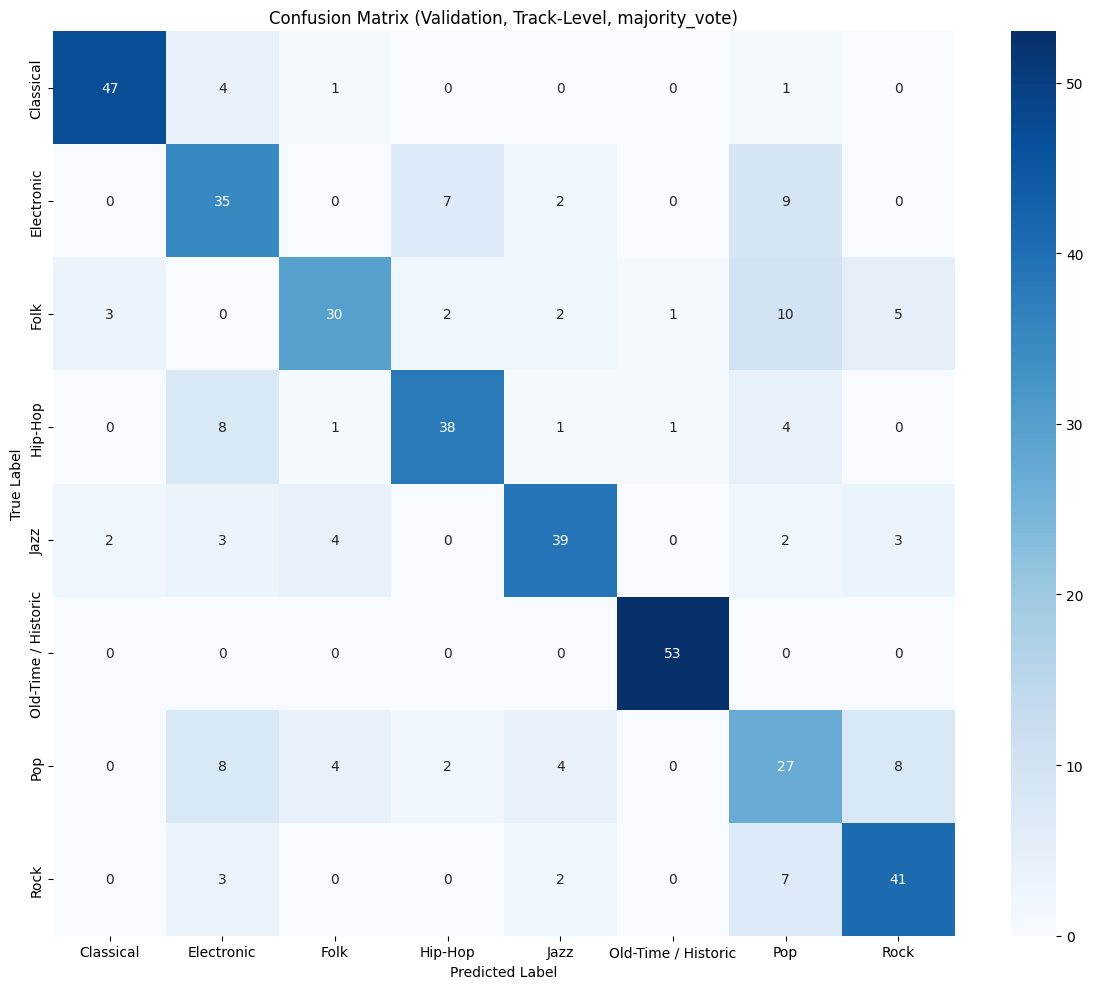


--- Test MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---
Accuracy: 0.7830188679245284
Macro-F1: 0.7808144734297099

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.87      0.88        53
         Electronic       0.64      0.74      0.68        53
               Folk       0.77      0.83      0.80        53
            Hip-Hop       0.87      0.75      0.81        53
               Jazz       0.86      0.81      0.83        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.51      0.43      0.47        53
               Rock       0.76      0.83      0.79        53

           accuracy                           0.78       424
          macro avg       0.78      0.78      0.78       424
       weighted avg       0.78      0.78      0.78       424



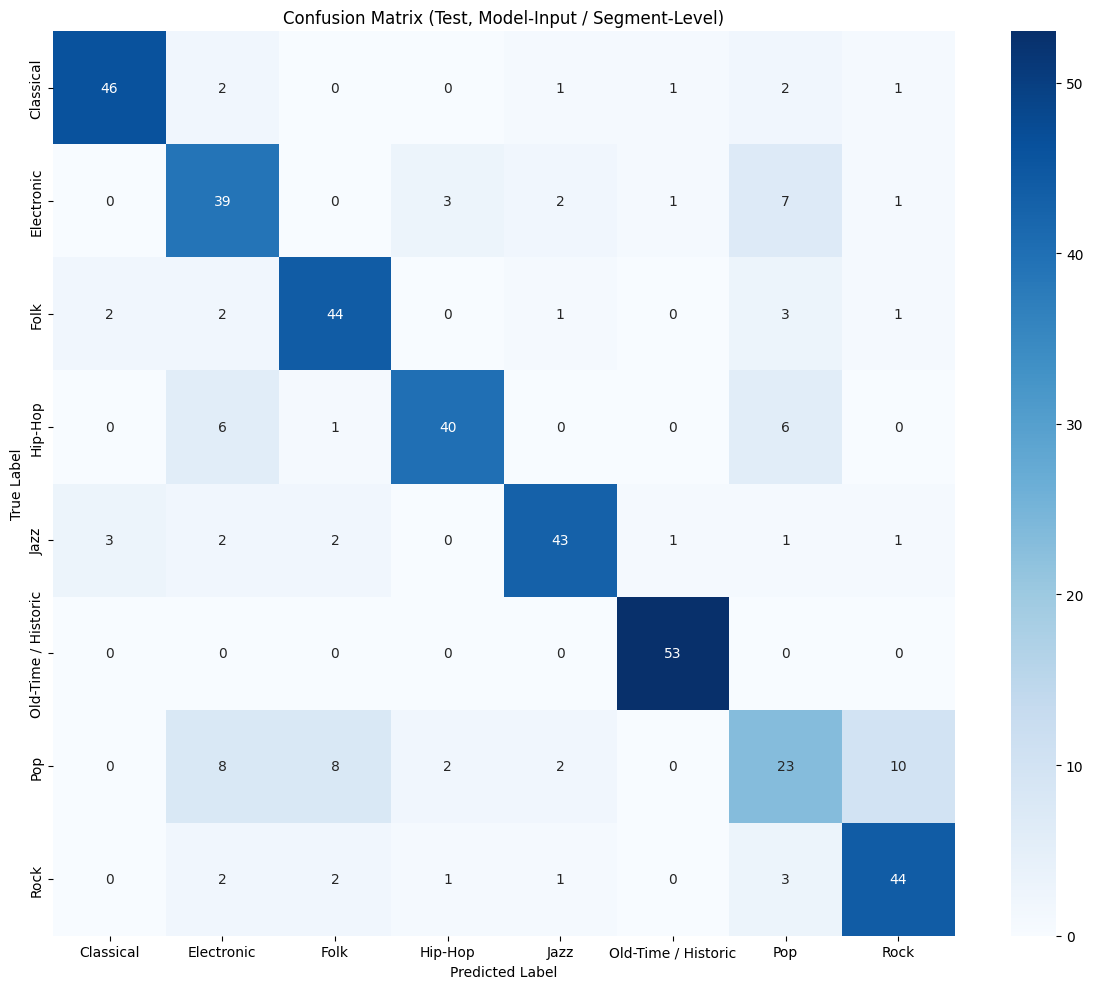


--- Test TRACK-LEVEL EVALUATION (mean_probability) ---
Accuracy: 0.7830188679245284
Macro-F1: 0.7808144734297099

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.87      0.88        53
         Electronic       0.64      0.74      0.68        53
               Folk       0.77      0.83      0.80        53
            Hip-Hop       0.87      0.75      0.81        53
               Jazz       0.86      0.81      0.83        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.51      0.43      0.47        53
               Rock       0.76      0.83      0.79        53

           accuracy                           0.78       424
          macro avg       0.78      0.78      0.78       424
       weighted avg       0.78      0.78      0.78       424



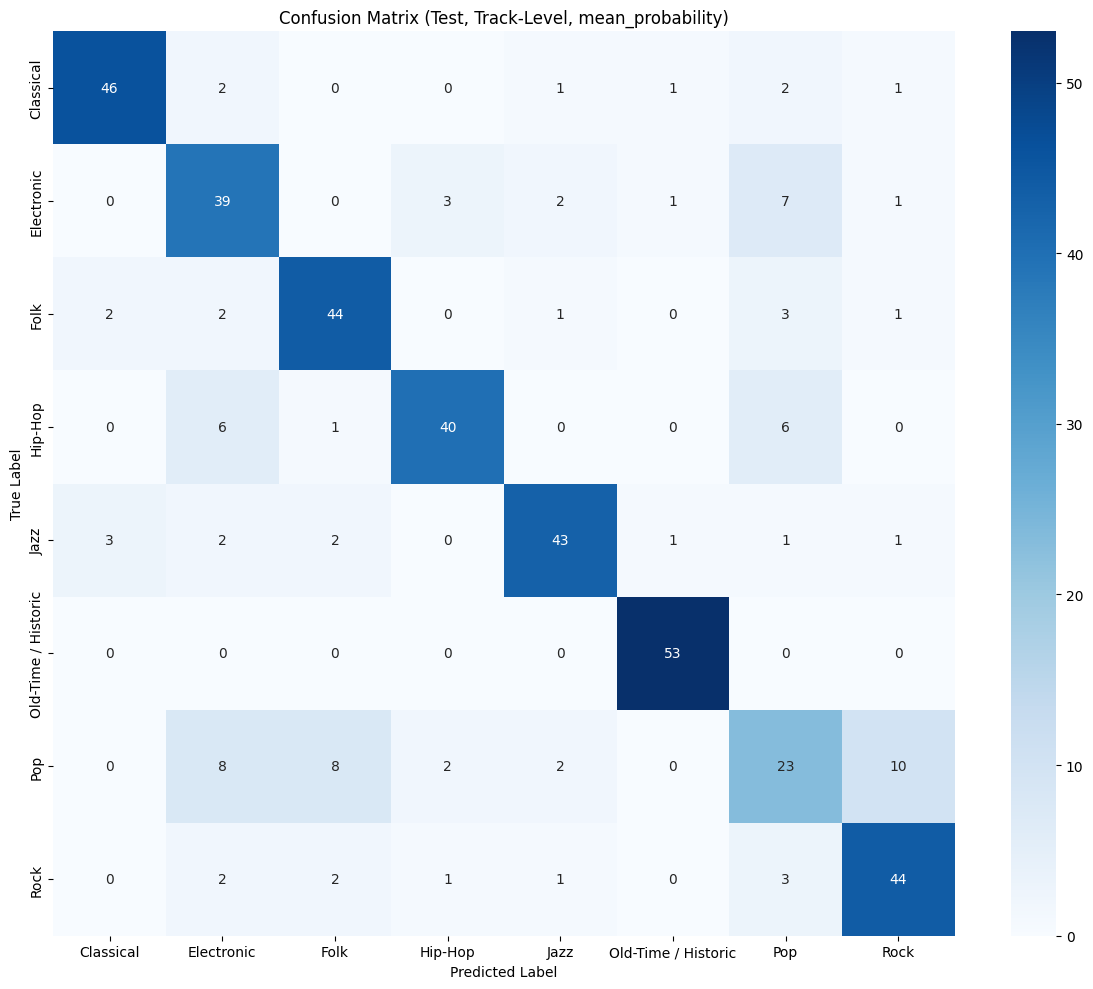


--- Test TRACK-LEVEL EVALUATION (majority_vote) ---
Accuracy: 0.7830188679245284
Macro-F1: 0.7808144734297099

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.87      0.88        53
         Electronic       0.64      0.74      0.68        53
               Folk       0.77      0.83      0.80        53
            Hip-Hop       0.87      0.75      0.81        53
               Jazz       0.86      0.81      0.83        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.51      0.43      0.47        53
               Rock       0.76      0.83      0.79        53

           accuracy                           0.78       424
          macro avg       0.78      0.78      0.78       424
       weighted avg       0.78      0.78      0.78       424



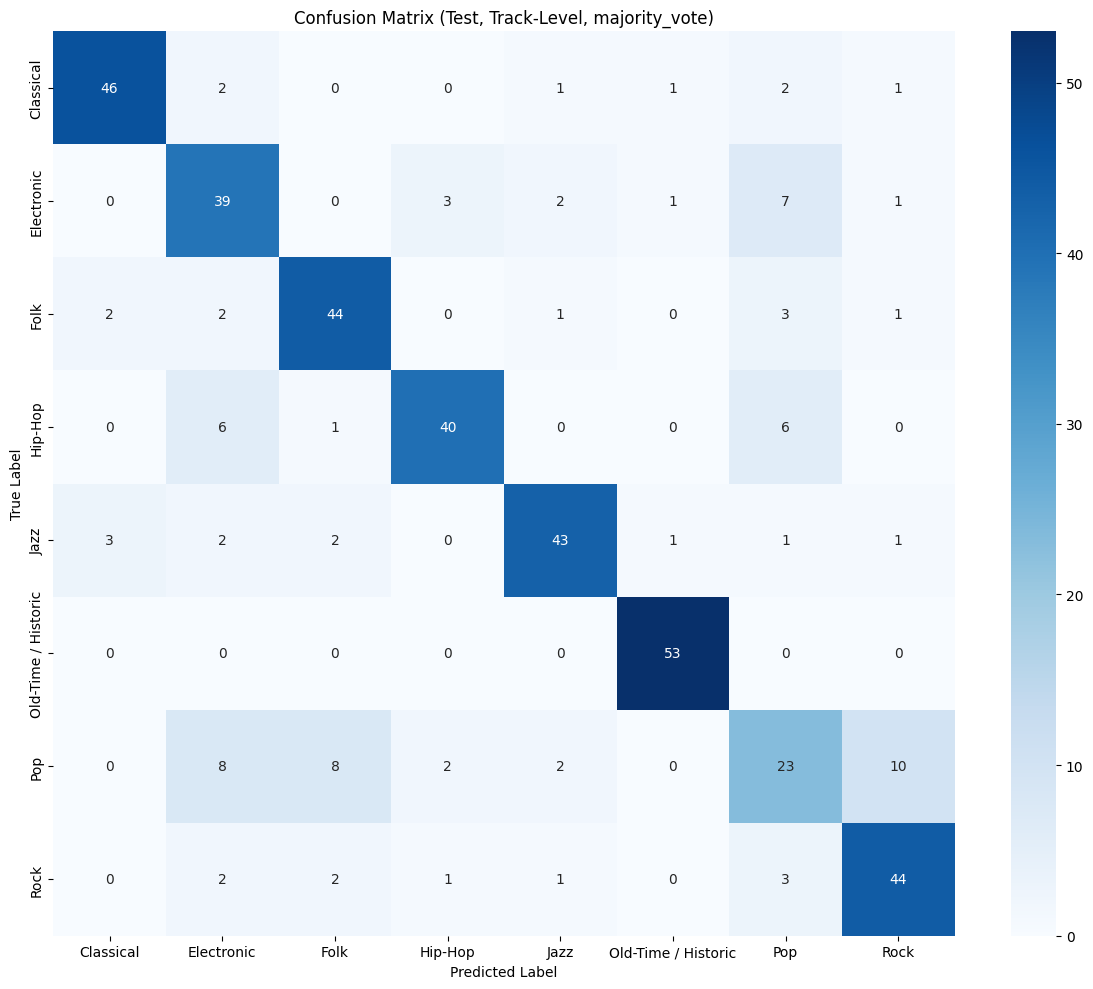

In [11]:
# ============================================================
# RUN MODEL-INPUT / SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# ============================================================

# Validation set
val_segment_df = collect_segment_predictions(model, val_loader)
evaluate_segment_predictions(val_segment_df, "Validation")

val_track_mean_df = aggregate_predictions_to_track(val_segment_df, method="mean_probability")
evaluate_track_predictions(val_track_mean_df, "Validation", method="mean_probability")

val_track_vote_df = aggregate_predictions_to_track(val_segment_df, method="majority_vote")
evaluate_track_predictions(val_track_vote_df, "Validation", method="majority_vote")


# Test set
test_segment_df = collect_segment_predictions(model, test_loader)
evaluate_segment_predictions(test_segment_df, "Test")

test_track_mean_df = aggregate_predictions_to_track(test_segment_df, method="mean_probability")
evaluate_track_predictions(test_track_mean_df, "Test", method="mean_probability")

test_track_vote_df = aggregate_predictions_to_track(test_segment_df, method="majority_vote")
evaluate_track_predictions(test_track_vote_df, "Test", method="majority_vote")


In [ ]:
# ============================================================
# SAVE TRACK-LEVEL RESULTS AND MISCLASSIFICATIONS
# ============================================================
# This saves the track-level misclassifications based on mean-probability
# aggregation. For the normal AST setup, this is usually identical to the
# model-input level because each track contributes one prediction. The export
# format is kept consistent with the 25 x 3-second AST notebooks.

if "test_track_mean_df" not in globals():
    test_segment_df = collect_segment_predictions(model, test_loader)
    test_track_mean_df = aggregate_predictions_to_track(
        test_segment_df,
        method="mean_probability"
    )

if "test_track_vote_df" not in globals():
    test_track_vote_df = aggregate_predictions_to_track(
        test_segment_df,
        method="majority_vote"
    )

misclassified_tracks_mean = test_track_mean_df[
    test_track_mean_df["true_label"] != test_track_mean_df["pred_label"]
].copy()

misclassified_tracks_vote = test_track_vote_df[
    test_track_vote_df["true_label"] != test_track_vote_df["pred_label"]
].copy()

print(f"Number of misclassified tracks (mean probability): {len(misclassified_tracks_mean)}")
print(misclassified_tracks_mean[["track_id", "true_genre", "predicted_genre", "n_segments"]].head())

results_dir = MODEL_RESULTS_DIR
os.makedirs(results_dir, exist_ok=True)

# Save all track-level test predictions for later analysis.
test_track_mean_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_track_level_mean_probability.csv"),
    index=False
)

test_track_vote_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_track_level_majority_vote.csv"),
    index=False
)

# Save only misclassified tracks for error analysis.
misclassified_tracks_mean[[
    "track_id",
    "true_genre",
    "predicted_genre",
    "n_segments",
    "aggregation_method"
]].to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_misclassified_tracks_track_level_mean_probability.csv"),
    index=False
)

misclassified_tracks_vote[[
    "track_id",
    "true_genre",
    "predicted_genre",
    "n_segments",
    "aggregation_method"
]].to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_misclassified_tracks_track_level_majority_vote.csv"),
    index=False
)

# Optional: save model-input / segment-level predictions as well.
test_segment_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_model_input_level.csv"),
    index=False
)


Number of misclassified tracks (mean probability): 92
   track_id true_genre      predicted_genre  n_segments
9      1064       Jazz                 Rock           1
13   108457        Pop                 Rock           1
20    10975       Jazz  Old-Time / Historic           1
24   110750    Hip-Hop                  Pop           1
27   111378        Pop                 Rock           1
